# pymor.vectorarrays

> Extended functionality for [pyMOR](https://pymor.org/) vector arrays

In [727]:
#| default_exp pymor.vectorarrays

## Imports -

In [728]:
#| hide
from fastcore.test import test_close, test_eq, test_fail
from nbdev.showdoc import show_doc

from pylgs.utilities.testing import test_da

In [729]:
#|export
from numbers import Number, Real
from functools import partial, cached_property
import inspect
from enum import StrEnum
import math

from fastcore.basics import patch, first
from fastcore.meta import delegates

import numpy as np
from numpy import array, ndarray
from sparse import SparseArray
import xarray as xr
from xarray import DataArray, Variable
from pymor.basic import NumpyVectorSpace
from pymor.core.base import classinstancemethod
from pymor.vectorarrays.interface import VectorArray, VectorArrayImpl, VectorSpace

from pylgs.utilities.basic import get_item, filter_args, filter_out_args
from pylgs.utilities.xarray import Coordinates
from pylgs.utilities.formatting import prefix_format

In [730]:
#|export
import pandas as pd
import plotly.express as px
import plotly

In [731]:
#|hide
test_da = partial(test_da, 'test_data/vectorarrays')
# def test_da(*args, **kwargs): pass

In [732]:
#|export
class Lbl(StrEnum):
    SRC = ' (source)'
    RNG = ' (range)'

In [733]:
#|export
def _unlabel_dims(obj):
    match obj:
        case str(): return obj.removesuffix(Lbl.SRC).removesuffix(Lbl.RNG)
        case list() | tuple(): return [_unlabel_dims(dim) for dim in obj]
        case dict(): return {_unlabel_dims(k): _unlabel_dims(v) for k,v in obj.items()}
        case Coordinates(): return Coordinates({_unlabel_dims(k): v.data for k,v in obj.items()})
        case DataArray(): return obj.rename({dim: _unlabel_dims(dim) for dim in obj.dims})
        case XarrayVectorSpace(): return obj.with_(coords_dict=_unlabel_dims(obj.coords))
    return obj

In [734]:
from sparse import COO, GCXS, SparseArray

## XarrayVectorSpace

### XarrayVectorSpace -

In [735]:
#|export
class XarrayVectorSpace(VectorSpace):
    """`VectorSpace` of `XarrayVectorArrays`."""

    def __init__(
        self, 
        coords_dict:Coordinates|dict|DataArray|None=None, 
        name:str|None=None, 
        attrs:dict|None=None, 
        id=None      # See `~pymor.vectorarrays.interface.VectorSpace.id`.
    ):
        # if isinstance(coords_dict, dict):
        #     coords = Coordinates(coords)
        # elif isinstance(coords, DataArray):
        #     if name is None: name = coords.name
        #     coords = Coordinates({dim: coords[dim] for dim in coords.dims})
        # # elif isinstance(coords, list):
        # #     coords = Coordinates({c.name: c.data for c in coords}) *** Do we need list input?        
        # self._array = DataArray(np.zeros(coords.shape if coords is not None else ()), coords=coords, name=name, attrs=attrs) 

        # self.dims = self._array.dims
        # self.__auto_init(locals())

        if isinstance(coords_dict, DataArray):
            if name is None: name = coords_dict.name
            coords_dict = coords_dict.coords
            if not coords_dict: raise ValueError("DataArray used to create XarrayVectorSpace must have defined coordinates.")
        if isinstance(coords_dict, Coordinates):
            coords_dict = dict(coords_dict)
        if not coords_dict: coords_dict = {}
        self.__auto_init(locals())
        self.dims = list(coords_dict)
        self.shape = [len(v) for v in coords_dict.values()]
        self.size = math.prod(self.shape)

    @cached_property
    def _array(self):
        return DataArray(
            np.zeros(self.shape),
            dims=self.dims,
            coords=self.coords_dict, 
            name=self.name, 
            attrs=self.attrs
        ) 
    
    @cached_property
    def coords(self):
        return self._array.coords
    
    @property
    def dim(self): return self._array.size
    
    @classmethod
    def _array_factory(cls, data, space, data_dims=None, extended_coords_dict=None):
        return XarrayVectorArray(space, XarrayVectorArrayImpl(data, space, data_dims, extended_coords_dict))

    @classinstancemethod
    def make_array(cls, obj, id=None):
        vec = cls._array_factory(obj, id=id)
        # vec.name = obj.name
        return vec

    @make_array.instancemethod
    def make_array(self, data, data_dims=None, extended_coords_dict=None):
        """:noindex:"""
        return self._array_factory(data, self, data_dims, extended_coords_dict)
    
    def zeros(
        self, 
        coords:dict|None=None, # Coordinates to extend vector space over
        reserve=0
    ): 
        raise NotImplementedError # Defined below
    
    def ones(
        self, 
        coords:dict|None=None, # Coordinates to extend vector space over
        reserve=0
    ): 
        raise NotImplementedError # Defined below

    # def __str__(self):
    #     return _coords_str(self.coords)

    # def short_str(self):
    #     return _short_coords_str(self.coords)
    
    def _repr_html_(self):
        return ' ⛒ '.join(f'<b>{k}</b>({len(v)})' for k,v in self.coords_dict.items())

    def __hash__(self):
        return hash(self.dim)

"Empty" `XarrayVectorSpace` with no coordinates (used, for example, for operators whose range is a scalar):

In [736]:
# space1 = XarrayVectorSpace()
# space1

In [737]:
#|hide
# test_eq(_.dim, 1)
# test_eq(_.shape, ())
# test_eq(_.dims, ())
# test_eq(_.name, 'XarrayVectorSpace')

`XarrayVectorSpace` from dictionary of coordinates:

In [738]:
coords = {'A': [1, 2, 3]}
space1 = XarrayVectorSpace(coords)
space1

XarrayVectorSpace(coords_dict={A: [1, 2, 3]})

In [739]:
#|hide
test_eq(_.shape, [3])
test_eq(_.dims, ['A'])
test_eq(_.name, 'XarrayVectorSpace')

In [740]:
coords = {'A': [1, 2, 3], 'B': ['a', 'b']}
space2 = XarrayVectorSpace(coords)
space2

XarrayVectorSpace(coords_dict={A: [1, 2, 3], B: ['a', 'b']})

In [741]:
#|hide
test_eq(_.shape, (3, 2))
test_eq(_.dims, ('A', 'B'))
test_eq(_.name, 'XarrayVectorSpace')

From xarray `Coordinates`:

In [742]:
coords = Coordinates(coords)
XarrayVectorSpace(coords)

XarrayVectorSpace(
    coords_dict={A: <xarray.DataArray 'A' (A: 3)> Size: 24B
                 array([1, 2, 3])
                 Coordinates:
                   * A        (A) int64 24B 1 2 3,
                 B: <xarray.DataArray 'B' (B: 2)> Size: 8B
                 array(['a', 'b'], dtype='<U1')
                 Coordinates:
                   * B        (B) <U1 8B 'a' 'b'})

In [743]:
#|hide
test_eq(_.shape, (3, 2))
test_eq(_.dims, ('A', 'B'))
test_eq(_.name, 'XarrayVectorSpace')

From `DataArray`:

In [744]:
da = DataArray(np.ones(coords.shape), coords=coords, name='C')
space = XarrayVectorSpace(da)
space

XarrayVectorSpace(
    coords_dict={A: <xarray.DataArray 'A' (A: 3)> Size: 24B
                 array([1, 2, 3])
                 Coordinates:
                   * A        (A) int64 24B 1 2 3,
                 B: <xarray.DataArray 'B' (B: 2)> Size: 8B
                 array(['a', 'b'], dtype='<U1')
                 Coordinates:
                   * B        (B) <U1 8B 'a' 'b'},
    name='C')

In [745]:
#|hide
test_eq(_.shape, (3, 2))
test_eq(_.dims, ('A', 'B'))
test_eq(_.name, 'C')

### ndim -


In [746]:
#|export
@patch(as_prop=True)
def ndim(self:XarrayVectorSpace): 
    """Number of dimensions of the vector space."""
    return self._array.ndim

In [747]:
space.ndim

2

In [748]:
#|hide
test_eq(_, 2)

### rename -

In [749]:
#|export
@patch
def rename(
    self:XarrayVectorSpace,
    name,
):
    return self.with_(name=name) #XarrayVectorSpace(self._array.rename(new_name_or_name_dict, **names))

In [750]:
space = XarrayVectorSpace({'A': [1, 2], 'B': ['a', 'b', 'c']}, name='boo')
space

XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo')

In [751]:
space.name

'boo'

In [752]:
#|hide
test_eq(_, 'boo')

In [753]:
space.rename('foo').name

'foo'

In [754]:
#|hide
test_eq(_, 'foo')

### __eq__ -


In [755]:
#|export
@patch
def __eq__(self:XarrayVectorSpace, other):
    return (
        type(other) is type(self) 
        and tuple(self.coords_dict) == tuple(other.coords_dict)
        ## NEED TO FIX THIS
        # and all((self.coords_dict[k] == other.coords_dict[k]) for k in self.coords_dict)
    )

In [756]:
space == space

True

In [757]:
#|hide
test_eq(_, True)

In [758]:
space == space.rename('foo')

True

In [759]:
#|hide
test_eq(_, True)

### __mul__ -


In [760]:
#|export
@patch
def __mul__(self:XarrayVectorSpace, other):
    if not isinstance(other, XarrayVectorSpace): raise NotImplementedError
    return XarrayVectorSpace((self._array * other._array).coords, name=other._array.name)

In [761]:
space2 = XarrayVectorSpace({'C': [1, 2], 'D': ['a', 'b', 'c']}, name='foo')

In [762]:
space3 = space * space2
space3

XarrayVectorSpace(
    coords_dict={A: <xarray.DataArray 'A' (A: 2)> Size: 16B
                 array([1, 2])
                 Coordinates:
                   * A        (A) int64 16B 1 2,
                 B: <xarray.DataArray 'B' (B: 3)> Size: 12B
                 array(['a', 'b', 'c'], dtype='<U1')
                 Coordinates:
                   * B        (B) <U1 12B 'a' 'b' 'c',
                 C: <xarray.DataArray 'C' (C: 2)> Size: 16B
                 array([1, 2])
                 Coordinates:
                   * C        (C) int64 16B 1 2,
                 D: <xarray.DataArray 'D' (D: 3)> Size: 12B
                 array(['a', 'b', 'c'], dtype='<U1')
                 Coordinates:
                   * D        (D) <U1 12B 'a' 'b' 'c'},
    name='foo')

In [763]:
space3 == XarrayVectorSpace(space.coords + space2.coords)

True

In [764]:
#|hide
test_eq(_, True)

In [765]:
space3.name

'foo'

In [766]:
#|hide
test_eq(_, 'foo')

In [767]:
space2 * space2 == space2

True

In [768]:
#|hide
test_eq(_, True)

## XarrayVectorArray

### XarrayVectorArrayImpl -

In [769]:
#|export
def transpose_like(a:ndarray, dims, new_dims):
    return a.transpose([dims.index(d) for d in new_dims])

In [770]:
#|export
#|hide
class XarrayVectorArrayImpl(VectorArrayImpl):

    def __init__(
        self, 
        _data:ndarray|DataArray, 
        _space, 
        _data_dims=None, 
        _extended_coords_dict=None
    ):
        if isinstance(_data, DataArray):
            _data_dims = _data.dims
            _extended_coords_dict = {k:v for k,v in _data.coords.items() if k not in _space.dims}
            _data = _data.data
        if isinstance(_data, SparseArray): 
            _data = _data.todense()
        if _data_dims is None:
            _data_dims = _space.dims
        if _extended_coords_dict is None:
            _extended_coords_dict = {}
        elif isinstance(_extended_coords_dict, Coordinates):
            _extended_coords_dict = dict(_extended_coords_dict)
        self._dims = list(_extended_coords_dict)
        all_dims = self._dims + _space.dims
        if set(all_dims) != set(_data_dims): raise ValueError(f'Data dims {_data_dims} do not match specified dims {all_dims}')
        if len(all_dims) != _data.ndim: raise ValueError(f'Dimensions {all_dims} do not match number of axes of data of shape {_data.shape}.')
        _data = transpose_like(_data, _data_dims, all_dims)
        _data_dims = all_dims
        self.__auto_init(locals())
        self._shape = _data.shape
        self._sizes = dict(zip(_data_dims, self._shape))
        self._array = None

    @property
    def array(self): 
        if self._array is None:
            self._array = DataArray(self._data, dims=self._data_dims, coords=self._space.coords_dict | self._extended_coords_dict)
        return self._array

    @property
    def _coords(self): return self.array.coords

    @property
    def _len(self): return self._data.size // self._space.size
    
    def __len__(self): return self._len

    def copy(self, deep, ind):
        _data = self._data if ind is None else self._data[ind].copy()
        return XarrayVectorArrayImpl(_data, self._space, self._data_dims, self._extended_coords_dict)
    
    def to_numpy(self, ensure_copy, ind): raise NotImplementedError
    def real(self, ind): raise NotImplementedError
    def imag(self, ind): raise NotImplementedError
    def conj(self, ind): raise NotImplementedError
    def delete(self, ind): raise NotImplementedError
    def append(self, other, remove_from_other, oind): raise NotImplementedError
    def scal(self, alpha, ind): raise NotImplementedError
    def scal_copy(self, alpha, ind): raise NotImplementedError
    def axpy(self, alpha, x, ind, xind): raise NotImplementedError
    def axpy_copy(self, alpha, x, ind, xind): raise NotImplementedError
    def inner(self, other, ind, oind): raise NotImplementedError
    def pairwise_inner(self, other, ind, oind): raise NotImplementedError
    def lincomb(self, coefficients, ind): raise NotImplementedError
    def norm(self, ind): raise NotImplementedError
    def norm2(self, ind): raise NotImplementedError
    def dofs(self, dof_indices, ind): raise NotImplementedError
    def amax(self, ind): raise NotImplementedError

In [771]:
impl = XarrayVectorArrayImpl(
    np.arange(6).reshape(2, 3, 1), 
    space, 
    ['A', 'B', 'C'], 
    {"C": [0]}
)
impl

XarrayVectorArrayImpl(
    array([[[0, 1, 2], [3, 4, 5]]]),
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    _data_dims=['C', 'A', 'B'],
    _extended_coords_dict={C: [0]})

In [772]:
len(impl)

1

In [773]:
#|hide
test_eq(_, 1)

In [774]:
impl.array

<xarray.DataArray (C: 1, A: 2, B: 3)> Size: 48B
array([[[0, 1, 2],
        [3, 4, 5]]])
Coordinates:
  * A        (A) int64 16B 1 2
  * B        (B) <U1 12B 'a' 'b' 'c'
  * C        (C) int64 8B 0

In [775]:
#|hide
test_da("XarrayVectorArray_array_with_extended_dimension", _)

In [776]:
# #|export
# #|hide
# def _abbreviate(s):
#     s = s.split('(')[0]
#     words = s.split()
#     if len(words) > 1: return ''.join(w[0].capitalize() for w in words)
#     return s[:2]

In [777]:
# #|export
# #|hide
# def _coords_str(coords, dims=None):
#     if not coords: return '{1}'
#     if dims is None: dims = list(coords)
#     return '{' + ' ⨉ '.join(f'{dim}({len(coords[dim])})' for dim in dims) + '}'

In [778]:
# #|export
# def _short_coords_str(coords, dims=None):
#     if not coords: return '{1}'
#     if dims is None: dims = list(coords)
#     return '{' + ' ⨉ '.join(f'{_abbreviate(dim)}({len(coords[dim])})' for dim in dims) + '}'

### XarrayVectorArray -

In [779]:
#|export
#|hide
class XarrayVectorArray(VectorArray):
    """`VectorArray` implementation via xarray arrays."""

    impl_type = XarrayVectorArrayImpl

    @property
    def data(self): return self.impl._data
    
    @property
    def array(self): return self.impl.array

    @property
    def shape(self): return self.impl._shape
    
    @property
    def coords(self): return self.impl._coords

    @property
    def dims(self): return self.impl._space.dims
    
    @property
    def extended_dims(self): return self.impl._dims

    @property
    def extended_coords(self): return self.impl._extended_coords_dict
    
    # def _coords_str(self, dims):
    #     if not dims: return '{1}'
    #     sizes = self.impl._sizes
    #     return '{' + ' ⨉ '.join(f'{dim}({sizes[dim]})' for dim in dims) + '}'        
    
    # def __str__(self):
    #     return self._coords_str(self.dims)[:-1] + ", " + self._coords_str(self.extended_dims)[1:]
    
    # def short_str(self):
    #     return _short_coords_str(self.space)[:-1] + ", " + _short_coords_str(self.coords, self.dims)[1:]
    
    def _repr_html_(self):
        space = self.space._repr_html_()
        extended = [f'{k}({len(v)})' for k,v in self.extended_coords.items()]
        if not extended: extended = ['∅']
        # return ' ⛒ '.join(extended) + f' ⛒ {space}'
        return f'''
            <details closed>
                <summary>
                    {' ⛒ '.join(extended + [space])}
                </summary>
                {self.array._repr_html_()}
            </details>
        '''

In [780]:
U = XarrayVectorArray(space, impl)
U

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[[0, 1, 2], [3, 4, 5]]]),
        XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
        _data_dims=['C', 'A', 'B'],
        _extended_coords_dict={C: [0]}),
    _len=1)

In [781]:
U.data

array([[[0, 1, 2],
        [3, 4, 5]]])

In [782]:
#|hide
test_eq(_, np.array([[[0, 1, 2], [3, 4, 5]]]))

In [783]:
U.array

<xarray.DataArray (C: 1, A: 2, B: 3)> Size: 48B
array([[[0, 1, 2],
        [3, 4, 5]]])
Coordinates:
  * A        (A) int64 16B 1 2
  * B        (B) <U1 12B 'a' 'b' 'c'
  * C        (C) int64 8B 0

In [784]:
#|hide
test_da("XarrayVectorArray_array_with_extended_dimension", _)

In [785]:
U.shape

(1, 2, 3)

In [786]:
#|hide
test_eq(_, (1,2,3))

In [787]:
U.coords

Coordinates:
  * A        (A) int64 16B 1 2
  * B        (B) <U1 12B 'a' 'b' 'c'
  * C        (C) int64 8B 0

In [788]:
#|hide
test_eq(list(_), ['A', 'B', 'C'])

In [789]:
U.dims

['A', 'B']

In [790]:
#|hide
test_eq(_, ['A', 'B'])

In [791]:
U.extended_dims

['C']

In [792]:
#|hide
test_eq(_, ['C'])

In [793]:
U.extended_coords

{'C': [0]}

In [794]:
#|hide
test_eq(_, {'C': [0]})

### from_data - 

In [795]:
#|export
@patch
def from_data(self:XarrayVectorSpace, data, data_dims=None, extended_coords_dict=None):
    return self.make_array(data, data_dims, extended_coords_dict)

Create a `VectorArray` with an extended dimension:

In [796]:
U = space.from_data(
    np.arange(6).reshape(2, 3, 1), 
    ['A', 'B', 'C'], 
    {"C": [0]}
)
U

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[[0, 1, 2], [3, 4, 5]]]),
        XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
        _data_dims=['C', 'A', 'B'],
        _extended_coords_dict={C: [0]}),
    _len=1)

In [797]:
U.data

array([[[0, 1, 2],
        [3, 4, 5]]])

In [798]:
#|hide
test_eq(_, np.array([[[0, 1, 2], [3, 4, 5]]]))

In [799]:
U.array

<xarray.DataArray (C: 1, A: 2, B: 3)> Size: 48B
array([[[0, 1, 2],
        [3, 4, 5]]])
Coordinates:
  * A        (A) int64 16B 1 2
  * B        (B) <U1 12B 'a' 'b' 'c'
  * C        (C) int64 8B 0

In [800]:
#|hide
test_da("XarrayVectorArray_array_with_extended_dimension", _)

In [801]:
U.shape

(1, 2, 3)

In [802]:
#|hide
test_eq(_, (1,2,3))

In [803]:
U.coords

Coordinates:
  * A        (A) int64 16B 1 2
  * B        (B) <U1 12B 'a' 'b' 'c'
  * C        (C) int64 8B 0

In [804]:
#|hide
test_eq(list(_), ['A', 'B', 'C'])

In [805]:
U.dims

['A', 'B']

In [806]:
#|hide
test_eq(_, ['A', 'B'])

In [807]:
U.extended_dims

['C']

In [808]:
#|hide
test_eq(_, ['C'])

In [809]:
U.extended_coords

{'C': [0]}

In [810]:
#|hide
test_eq(_, {'C': [0]})

Create a `VectorArray` with no extended dimension:

In [811]:
U = space.from_data(
    np.arange(6).reshape(2, 3),
    ['A', 'B'],
)
U

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[0, 1, 2], [3, 4, 5]]),
        XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
        _data_dims=['A', 'B'],
        _extended_coords_dict={}),
    _len=1)

In [812]:
U.data

array([[0, 1, 2],
       [3, 4, 5]])

In [813]:
#|hide
test_eq(_, np.array([[0, 1, 2], [3, 4, 5]]))

In [814]:
U.array

<xarray.DataArray (A: 2, B: 3)> Size: 48B
array([[0, 1, 2],
       [3, 4, 5]])
Coordinates:
  * A        (A) int64 16B 1 2
  * B        (B) <U1 12B 'a' 'b' 'c'

In [815]:
#|hide
test_da("XarrayVectorArray_array_no_extended_dimension", _)

In [816]:
U.shape

(2, 3)

In [817]:
#|hide
test_eq(_, (2, 3))

In [818]:
U.coords

Coordinates:
  * A        (A) int64 16B 1 2
  * B        (B) <U1 12B 'a' 'b' 'c'

In [819]:
#|hide
test_eq(list(_), ['A', 'B'])

In [820]:
U.dims

['A', 'B']

In [821]:
#|hide
test_eq(_, ['A', 'B'])

In [822]:
U.extended_dims

[]

In [823]:
#|hide
test_eq(_, [])

In [824]:
U.extended_coords

{}

In [825]:
#|hide
test_eq(_, {})

### from_numpy -

In [826]:
#|export
@patch
def from_numpy(
    self:XarrayVectorSpace, 
    data:ndarray, 
    extended_coords:dict|str|None=None, 
    id=None, 
    ensure_copy=False
)->XarrayVectorArray: # A vector array with data from the numpy array
    """Return an `XarrayVectorArray` in the vector space with data from the `ndarray` `data`."""
    if ensure_copy: data = data.copy()
    if extended_coords is None:
        extended_coords = {}
    elif isinstance(extended_coords, str):
        extended_coords = {extended_coords: np.arange(data.size // self.dim)}
    extended_shape = [len(v) for v in extended_coords.values()]
    shape = extended_shape + self.shape
    return self.from_data(data.reshape(shape), list(extended_coords) + self.dims, extended_coords)

In [827]:
space.from_numpy(np.arange(6))

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[0, 1, 2], [3, 4, 5]]),
        XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
        _data_dims=['A', 'B'],
        _extended_coords_dict={}),
    _len=1)

In [828]:
#|hide
test_da("XarrayVectorArray_array_no_extended_dimension", _.array)

In [829]:
space.from_numpy(np.arange(6), {"C": [0]})

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[[0, 1, 2], [3, 4, 5]]]),
        XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
        _data_dims=['C', 'A', 'B'],
        _extended_coords_dict={C: [0]}),
    _len=1)

In [830]:
#|hide
test_da("XarrayVectorArray_array_with_extended_dimension", _.array)

### from_xarray -

In [831]:
#|export
@patch
def from_xarray(
    self:XarrayVectorSpace, 
    data:DataArray
)->XarrayVectorArray:
    """Return an `XarrayVectorArray` containing data from `DataArray` `data`."""
    # extended_coords = {k:v for k,v in data.coords.items() if k not in self.dims}
    return self.from_data(data)

In [832]:
da = space.from_numpy(np.arange(6)).array
da

<xarray.DataArray (A: 2, B: 3)> Size: 48B
array([[0, 1, 2],
       [3, 4, 5]])
Coordinates:
  * A        (A) int64 16B 1 2
  * B        (B) <U1 12B 'a' 'b' 'c'

In [833]:
space.from_xarray(da)

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[0, 1, 2], [3, 4, 5]]),
        XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
        _data_dims=['A', 'B'],
        _extended_coords_dict={}),
    _len=1)

In [834]:
#|hide
test_da("XarrayVectorArray_array_no_extended_dimension", _.array)

An `XarrayVectorArray` from an array in `space` plus extended dimensions:

In [835]:
da = da * DataArray([1], coords=[('C', [0])])
da

<xarray.DataArray (A: 2, B: 3, C: 1)> Size: 48B
array([[[0],
        [1],
        [2]],

       [[3],
        [4],
        [5]]])
Coordinates:
  * A        (A) int64 16B 1 2
  * B        (B) <U1 12B 'a' 'b' 'c'
  * C        (C) int64 8B 0

In [836]:
space.from_xarray(da)

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[[0, 1, 2], [3, 4, 5]]]),
        XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
        _data_dims=['C', 'A', 'B'],
        _extended_coords_dict={C: <xarray.DataArray 'C' (C: 1)> Size: 8B
                               array([0])
                               Coordinates:
                                 * C        (C) int64 8B 0}),
    _len=1)

In [837]:
#|hide
test_da("XarrayVectorArray_array_with_extended_dimension", _.array)

### concatenate -


In [838]:
# #|export
# @patch
# def concatenate(self:XarrayVectorSpace, arrays, dim):
#     return self.from_xarray(xr.concat([array.array for array in arrays], Variable(first(dim), first(dim.values()))))

### zeros -

In [839]:
#|export
@patch
def array_from_fn(
    self:XarrayVectorSpace,
    fn,
    coords:dict|None=None, # Coordinates to extend vector space over
    reserve=0,
)->XarrayVectorArray: # `XarrayVectorArray` with all elements equal to zero
    """Return `XarrayVectorArray` of null vectors in XarrayVectorSpace optionally extended to include supplied coordinates `coords`."""
    if coords is None: coords = {}
    shape = [len(c) for c in coords.values()]
    data = fn(shape + self.shape)
    return self.from_data(data, list(coords) + self.dims, coords)

In [840]:
#|export
@patch
def zeros(
    self:XarrayVectorSpace, 
    coords:dict|None=None, # Coordinates to extend vector space over
    reserve:int=0
)->XarrayVectorArray: # `XarrayVectorArray` with all elements equal to zero
    """Return `XarrayVectorArray` of null vectors in XarrayVectorSpace optionally extended to include supplied coordinates `coords`."""
    return self.array_from_fn(np.zeros, coords, reserve)

In [841]:
space.zeros()

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[0., 0., 0.], [0., 0., 0.]]),
        XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
        _data_dims=['A', 'B'],
        _extended_coords_dict={}),
    _len=1)

In [842]:
#|hide
test_da('XarrayVectorSpace_zeros_no_extension', _.array)

In [843]:
space.zeros({'C': [0]})

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[[0., 0., 0.], [0., 0., 0.]]]),
        XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
        _data_dims=['C', 'A', 'B'],
        _extended_coords_dict={C: [0]}),
    _len=1)

In [844]:
#|hide
test_da('XarrayVectorSpace_zeros_with_extension', _.array)

### ones -

In [845]:
#|export
@patch
def ones(
    self:XarrayVectorSpace, 
    coords:dict|None=None, # Coordinates to extend vector space over
    reserve:int=0
)->XarrayVectorArray: # `XarrayVectorArray` with all elements equal to one
    """Return `XarrayVectorArray` of vectors with each element equal to one in XarrayVectorSpace optionally extended to include supplied coordinates `coords`."""
    return self.array_from_fn(np.ones, coords, reserve)

In [846]:
space.ones()

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[1., 1., 1.], [1., 1., 1.]]),
        XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
        _data_dims=['A', 'B'],
        _extended_coords_dict={}),
    _len=1)

In [847]:
#|hide
test_da('XarrayVectorSpace_ones_no_extension', _.array)

In [848]:
space.ones({'C': [0]})

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[[1., 1., 1.], [1., 1., 1.]]]),
        XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
        _data_dims=['C', 'A', 'B'],
        _extended_coords_dict={C: [0]}),
    _len=1)

In [849]:
#|hide
test_da('XarrayVectorSpace_ones_with_extension', _.array)

### random -

In [850]:
#|export
from pymor.vectorarrays.interface import _create_random_values

In [851]:
#|export
@patch
def random(
    self:XarrayVectorSpace, 
    coords=None, 
    distribution='uniform',
    name=None
)->XarrayVectorArray: # A random `XarrayVectorArray` in the vector space
    out = self.array_from_fn(lambda shape: _create_random_values(shape, distribution), coords)
    if name is not None: out.name = name
    return out

In [852]:
from pymor.tools.random import new_rng

In [853]:
with new_rng(42):
    U = space.random()
U

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[0.77395605, 0.85859792, 0.09417735], [0.43887844, 0.69736803, 0.97562235]]),
        XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
        _data_dims=['A', 'B'],
        _extended_coords_dict={}),
    _len=1)

In [854]:
#|hide
test_da('XarrayVectorSpace_random_no_extension', _.array)

In [855]:
with new_rng(42):
    U = space.random({'C': [0]})
U

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[[0.77395605, 0.85859792, 0.09417735], [0.43887844, 0.69736803, 0.97562235]]]),
        XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
        _data_dims=['C', 'A', 'B'],
        _extended_coords_dict={C: [0]}),
    _len=1)

In [856]:
#|hide
test_da('XarrayVectorSpace_random_with_extension', _.array)

### __contains__ -


In [857]:
#|export
@patch
def __contains__(self:XarrayVectorSpace, other):
    # This is reversed because when pymor calls `assert U in op.source`
    # we really want to assert that the source of `op` is one of the coordinates of `U`, 
    # which more logically would be written "assert op.source in U"
    if isinstance(other, XarrayVectorSpace):
        return other._array.coords.contain(self._array.coords)
    elif isinstance(other, XarrayVectorArray):
        return other.space._array.coords.contain(self._array.coords)
    return False

In [858]:
space in space2

False

In [859]:
#|hide
test_eq(_, False)

In [860]:
space in space

True

In [861]:
#|hide
test_eq(_, True)

In [862]:
U = space.zeros({'C': range(2)})
U

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[[0., 0., 0.], [0., 0., 0.]],  [[0., 0., 0.], [0., 0., 0.]]]),
        XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
        _data_dims=['C', 'A', 'B'],
        _extended_coords_dict={C: range(0, 2)}),
    _len=2)

In [863]:
U in space

True

In [864]:
#|hide
test_eq(_, True)

### array_labeled_as_source -

In [865]:
#|export
@patch
def array_labeled_as_source(self:XarrayVectorArray):
    return self.array.rename({d: d + Lbl.SRC for d in self.dims})

In [866]:
U.array_labeled_as_source()

<xarray.DataArray (C: 2, A (source): 2, B (source): 3)> Size: 96B
array([[[0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.]]])
Coordinates:
  * A (source)  (A (source)) int64 16B 1 2
  * B (source)  (B (source)) <U1 12B 'a' 'b' 'c'
  * C           (C) int64 16B 0 1

In [867]:
#|hide
test_da("XarrayVectorArray_array_labeled_as_source", _)

### item -

In [868]:
#|export
@patch
def item(self:XarrayVectorArray):
    """Return the single value stored in the array if there is only one value."""
    return self.data.item()

In [869]:
XarrayVectorSpace({'i': [0]}).ones().item()

1.0

In [870]:
#| hide
test_close(_, 1)

### dims -


In [871]:
# #|export
# @patch(as_prop=True)
# def dims(self:XarrayVectorArray): return self.array.dims

### stacked_array -


In [872]:
#|export
#|hide
@patch(as_prop=True)
def stacked_array(self:XarrayVectorArrayImpl):
    core = {'core': self._space.dims} if self._space.dims else {}
    extended = {'extended': self._dims} if self._dims else {}
    return self.array.stack(core | extended, create_index=False)

In [873]:
#|hide
U.impl.stacked_array

<xarray.DataArray (core: 6, extended: 2)> Size: 96B
array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.]])
Coordinates:
    A        (core) int64 48B 1 1 1 2 2 2
    B        (core) <U1 24B 'a' 'b' 'c' 'a' 'b' 'c'
    C        (extended) int64 16B 0 1
Dimensions without coordinates: core, extended

In [874]:
#|hide
test_da("XarrayVectorArrayImpl_stacked_array", _)

### to_numpy -


In [875]:
#|export
#|hide
@patch
def to_numpy(self:XarrayVectorArrayImpl, ensure_copy, ind):
    if ind is not None: raise NotImplementedError
    array = self.stacked_array.to_numpy()
    if not self._space.dims: array = array[None, :]
    if not self._dims: array = array[:, None]
    if ensure_copy and not array.flags['OWNDATA']:
        return array.copy()
    else:
        return array

In [876]:
show_doc(XarrayVectorArray.to_numpy)

---

### VectorArray.to_numpy

>      VectorArray.to_numpy (ensure_copy=False)

*Return (self.dim, len(self)) NumPy Array with the data stored in the array.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| ensure_copy | bool | False | If `False`, modifying the returned \|NumPy array\| might alter the original<br>\|VectorArray\|. If `True` always a copy of the array data is made. |

In [877]:
U.to_numpy().shape

(6, 2)

This gives the same result as for a dimension-6 `NumpyVectorSpace`:

In [878]:
NumpyVectorSpace(6).zeros(2).to_numpy().shape

(6, 2)

In [879]:
#|hide
test_eq(__, _)

In [880]:
#|hide
test_eq(
    XarrayVectorSpace({'x': np.arange(6)}).zeros().to_numpy(),
    NumpyVectorSpace(6).zeros().to_numpy()
)

In [881]:
space.zeros(space2.coords).shape

(2, 3, 2, 3)

In [882]:
space.zeros(space2.coords).to_numpy().shape

(6, 6)

In [883]:
#|hide
test_eq(_, (6, 6))

### rename -


In [884]:
# #|export
# @patch
# def rename(
#     self:XarrayVectorArray,
#     new_name_or_name_dict=None,
#     **names,
# ):
#     """Rename the vector array and/or any of its dimensions."""
#     vec = self.space.rename(new_name_or_name_dict, **names).from_xarray(self.array.rename(new_name_or_name_dict, **names))
#     if isinstance(new_name_or_name_dict, str): vec.name = new_name_or_name_dict
#     return vec

In [885]:
# U.rename('baz', A='bar')

In [886]:
#|hide
# test_eq(_.name, 'baz')

### scal -


In [887]:
#|export
#|hide
@patch
def scal(self:XarrayVectorArrayImpl, alpha, ind):
    if ind is not None: raise NotImplementedError
    self._data *= alpha

In [888]:
space

XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo')

In [889]:
U = space.ones({'C': [0]})
U

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[[1., 1., 1.], [1., 1., 1.]]]),
        XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
        _data_dims=['C', 'A', 'B'],
        _extended_coords_dict={C: [0]}),
    _len=1)

In [890]:
U.scal(2)

In [891]:
U.data

array([[[2., 2., 2.],
        [2., 2., 2.]]])

In [892]:
#|hide
test_eq(_, np.array([[[2., 2., 2.], [2., 2., 2.]]]))

In [893]:
#|hide
test_da("XarrayVectorArrayImpl_scal", U.array)

### scal_copy -


In [894]:
#|export
#|hide
@patch
def scal_copy(self:XarrayVectorArrayImpl, alpha, ind):
    if ind is not None: raise NotImplementedError
    return type(self)(self._data * alpha, self._space, self._data_dims, self._extended_coords_dict)

In [895]:
U * 1j

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[[0.+2.j, 0.+2.j, 0.+2.j], [0.+2.j, 0.+2.j, 0.+2.j]]]),
        XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
        _data_dims=['C', 'A', 'B'],
        _extended_coords_dict={C: [0]}),
    _len=1)

In [896]:
#|hide
test_da("XarrayVectorArrayImpl_scal_copy", _.array)

### axpy -


In [897]:
#|export
#|hide
@patch
def axpy(self:XarrayVectorArrayImpl, alpha, x, ind, xind):
    if ind is not None: raise NotImplementedError
    B = x._data
    if isinstance(alpha, Number):
        if alpha == 1:
            self._data += B
            return
        elif alpha == -1:
            self._data -= B
            return

    self._data += B * alpha

In [898]:
U1 = space.ones({'C': [0]})
U1

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[[1., 1., 1.], [1., 1., 1.]]]),
        XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
        _data_dims=['C', 'A', 'B'],
        _extended_coords_dict={C: [0]}),
    _len=1)

In [899]:
U2 = space.ones()
U2

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[1., 1., 1.], [1., 1., 1.]]),
        XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
        _data_dims=['A', 'B'],
        _extended_coords_dict={}),
    _len=1)

In [900]:
U1.axpy(2, U2)

In [901]:
U1

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[[3., 3., 3.], [3., 3., 3.]]]),
        XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
        _data_dims=['C', 'A', 'B'],
        _extended_coords_dict={C: [0]}),
    _len=1)

In [902]:
#|hide
test_da("XarrayVectorArrayImpl_axpy", _.array)

In [903]:
U1 = space.ones({'C': [0]})
U1

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[[1., 1., 1.], [1., 1., 1.]]]),
        XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
        _data_dims=['C', 'A', 'B'],
        _extended_coords_dict={C: [0]}),
    _len=1)

In [904]:
U1.axpy(2, U1)

In [905]:
U1

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[[3., 3., 3.], [3., 3., 3.]]]),
        XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
        _data_dims=['C', 'A', 'B'],
        _extended_coords_dict={C: [0]}),
    _len=1)

In [906]:
#|hide
test_da("XarrayVectorArrayImpl_axpy", _.array)

### axpy_copy -


In [907]:
#|export
#|hide
@patch
def axpy_copy(self:XarrayVectorArrayImpl, alpha, x, ind, xind):
    if ind is not None or xind is not None: raise NotImplementedError
    B = x._data
    # if issparse(B): B = B.todense()
    if isinstance(alpha, Number):
        if alpha == 1:
            return type(self)(self._data + B, self._space, self._data_dims, self._extended_coords_dict)
        elif alpha == -1:
            return type(self)(self._data - B, self._space, self._data_dims, self._extended_coords_dict)
    return type(self)(self._data + B * alpha, self._space, self._data_dims, self._extended_coords_dict)

In [908]:
U1 = space.ones({'C': [0]})
U1

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[[1., 1., 1.], [1., 1., 1.]]]),
        XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
        _data_dims=['C', 'A', 'B'],
        _extended_coords_dict={C: [0]}),
    _len=1)

In [909]:
U1 + U1

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[[2., 2., 2.], [2., 2., 2.]]]),
        XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
        _data_dims=['C', 'A', 'B'],
        _extended_coords_dict={C: [0]}),
    _len=1)

In [910]:
#|hide
test_da("XarrayVectorArrayImpl_axpy_copy", _.array)

In [911]:
U2 = space.ones()

In [912]:
U1 + U2

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[[2., 2., 2.], [2., 2., 2.]]]),
        XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
        _data_dims=['C', 'A', 'B'],
        _extended_coords_dict={C: [0]}),
    _len=1)

In [913]:
#|hide
test_da("XarrayVectorArrayImpl_axpy_copy", _.array)

### mul -

In [914]:
#|export
@patch
def __mul__(self:XarrayVectorArray, other):
    match other:
        case DataArray():
            other = _unlabel_dims(other)
            if self.coords.contain(other.coords):
                out = self.space.from_xarray(self.array * other)
                out.name = self.name
                return out
            else:
                raise ValueError("DataArray coordinates are not a subset of VectorArray coordinates.")
        case XarrayVectorArray(): 
            out = (self.space * other.space).from_xarray(self.array * other.array)
            out.name = self.name
            return out
        case Number():
            return type(self)(self.space, self.impl.scal_copy(other, self.ind))
    raise NotImplementedError

In [915]:
U1 = space.ones({'C': [0]})

In [916]:
da = DataArray(np.arange(3), {'B': U1.array.B})
da

<xarray.DataArray (B: 3)> Size: 24B
array([0, 1, 2])
Coordinates:
  * B        (B) <U1 12B 'a' 'b' 'c'

In [917]:
U1 * da

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[[0., 1., 2.], [0., 1., 2.]]]),
        XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
        _data_dims=['C', 'A', 'B'],
        _extended_coords_dict={C: <xarray.DataArray 'C' (C: 1)> Size: 8B
                               array([0])
                               Coordinates:
                                 * C        (C) int64 8B 0}),
    _len=1)

In [918]:
#|hide
test_da("XarrayVectorArray_mul_shared_dimension", _.array)

In [919]:
space.ones() * space2.zeros()

XarrayVectorArray(
    XarrayVectorSpace(
        coords_dict={A: <xarray.DataArray 'A' (A: 2)> Size: 16B
                     array([1, 2])
                     Coordinates:
                       * A        (A) int64 16B 1 2,
                     B: <xarray.DataArray 'B' (B: 3)> Size: 12B
                     array(['a', 'b', 'c'], dtype='<U1')
                     Coordinates:
                       * B        (B) <U1 12B 'a' 'b' 'c',
                     C: <xarray.DataArray 'C' (C: 2)> Size: 16B
                     array([1, 2])
                     Coordinates:
                       * C        (C) int64 16B 1 2,
                     D: <xarray.DataArray 'D' (D: 3)> Size: 12B
                     array(['a', 'b', 'c'], dtype='<U1')
                     Coordinates:
                       * D        (D) <U1 12B 'a' 'b' 'c'},
        name='foo'),
    XarrayVectorArrayImpl(
        array([[[[0., 0., 0.],
                 [0., 0., 0.]],

                [[0., 0., 0.],
                 [0., 0., 0.]],

                [[0., 0., 0.],
                 [0., 0., 0.]]],


               [[[0., 0., 0.],
                 [0., 0., 0.]],

                [[0., 0., 0.],
                 [0., 0., 0.]],

                [[0., 0., 0.],
                 [0., 0., 0.]]]]),
        XarrayVectorSpace(
            coords_dict={A: <xarray.DataArray 'A' (A: 2)> Size: 16B
                         array([1, 2])
                         Coordinates:
                           * A        (A) int64 16B 1 2,
                         B: <xarray.DataArray 'B' (B: 3)> Size: 12B
                         array(['a', 'b', 'c'], dtype='<U1')
                         Coordinates:
                           * B        (B) <U1 12B 'a' 'b' 'c',
                         C: <xarray.DataArray 'C' (C: 2)> Size: 16B
                         array([1, 2])
                         Coordinates:
                           * C        (C) int64 16B 1 2,
                         D: <xarray.DataArray 'D' (D: 3)> Size: 12B
                         array(['a', 'b', 'c'], dtype='<U1')
                         Coordinates:
                           * D        (D) <U1 12B 'a' 'b' 'c'},
            name='foo'),
        _data_dims=['A', 'B', 'C', 'D'],
        _extended_coords_dict={}),
    _len=1)

In [920]:
#|hide
test_da("XarrayVectorArray_mul_different_dimensions", _.array)

In [921]:
U1 = space.ones()
U1

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[1., 1., 1.], [1., 1., 1.]]),
        XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
        _data_dims=['A', 'B'],
        _extended_coords_dict={}),
    _len=1)

In [922]:
U2 = XarrayVectorSpace(U1.array.B).from_numpy(np.arange(3), extended_coords={'C': [0]})
U2

XarrayVectorArray(
    XarrayVectorSpace(
        coords_dict={B: <xarray.DataArray 'B' (B: 3)> Size: 12B
                     array(['a', 'b', 'c'], dtype='<U1')
                     Coordinates:
                       * B        (B) <U1 12B 'a' 'b' 'c'},
        name='B'),
    XarrayVectorArrayImpl(
        array([[0, 1, 2]]),
        XarrayVectorSpace(
            coords_dict={B: <xarray.DataArray 'B' (B: 3)> Size: 12B
                         array(['a', 'b', 'c'], dtype='<U1')
                         Coordinates:
                           * B        (B) <U1 12B 'a' 'b' 'c'},
            name='B'),
        _data_dims=['C', 'B'],
        _extended_coords_dict={C: [0]}),
    _len=1)

In [923]:
U1 * U2

XarrayVectorArray(
    XarrayVectorSpace(
        coords_dict={A: <xarray.DataArray 'A' (A: 2)> Size: 16B
                     array([1, 2])
                     Coordinates:
                       * A        (A) int64 16B 1 2,
                     B: <xarray.DataArray 'B' (B: 3)> Size: 12B
                     array(['a', 'b', 'c'], dtype='<U1')
                     Coordinates:
                       * B        (B) <U1 12B 'a' 'b' 'c'},
        name='B'),
    XarrayVectorArrayImpl(
        array([[[0., 1., 2.], [0., 1., 2.]]]),
        XarrayVectorSpace(
            coords_dict={A: <xarray.DataArray 'A' (A: 2)> Size: 16B
                         array([1, 2])
                         Coordinates:
                           * A        (A) int64 16B 1 2,
                         B: <xarray.DataArray 'B' (B: 3)> Size: 12B
                         array(['a', 'b', 'c'], dtype='<U1')
                         Coordinates:
                           * B        (B) <U1 12B 'a' 'b' 'c'},
            name='B'),
        _data_dims=['C', 'A', 'B'],
        _extended_coords_dict={C: <xarray.DataArray 'C' (C: 1)> Size: 8B
                               array([0])
                               Coordinates:
                                 * C        (C) int64 8B 0}),
    _len=1)

In [924]:
#|hide
test_da("XarrayVectorArray_mul_extended_dimension", _.array)

In [925]:
U1 * 1j

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[0.+1.j, 0.+1.j, 0.+1.j], [0.+1.j, 0.+1.j, 0.+1.j]]),
        XarrayVectorSpace(coords_dict={A: [1, 2], B: ['a', 'b', 'c']}, name='boo'),
        _data_dims=['A', 'B'],
        _extended_coords_dict={}),
    _len=1)

In [926]:
#|hide
test_da("XarrayVectorArray_mul_scalar", _.array)

In [927]:
#|hide
test_fail(lambda:U1 * 'foo', exc=NotImplementedError)

### real -


In [928]:
#|export
#|hide
def _reim(da:DataArray):
    return xr.concat([da.real, da.imag], dim=xr.Variable('Part', ['Re', 'Im'])).transpose(*da.dims, 'Part')

In [929]:
#|export
#|hide
@patch
def real(self:XarrayVectorArrayImpl, ind):
    return XarrayVectorArrayImpl(self.copy(False, ind)._data.real, self._space, self._data_dims, self._extended_coords_dict)
    
@patch
def imag(self:XarrayVectorArrayImpl, ind):
    return XarrayVectorArrayImpl(self.copy(False, ind)._data.imag, self._space, self._data_dims, self._extended_coords_dict)
    
@patch
def conj(self:XarrayVectorArrayImpl, ind):
    if np.isrealobj(self._array):
        return self.copy(False, ind)
    return XarrayVectorArrayImpl(np.conj(self.copy(False, ind)._data), self._space, self._data_dims, self._extended_coords_dict)
    
@patch
def reim(self:XarrayVectorArrayImpl):
    return XarrayVectorArrayImpl(np.array([self._data.real, self._data.imag]), self._space, ['Part'] + self._data_dims, {'Part': ['Re', 'Im']} | self._extended_coords_dict)
    
@patch(as_prop=True)
def reim(self:XarrayVectorArray):
    impl = self.impl.reim()
    if impl is self.impl:
        return self.copy()
    else:
        return type(self)(self.space, impl)

In [930]:
space = XarrayVectorSpace({'A': [1], 'B': ['a', 'b']}, name='boo')
space

XarrayVectorSpace(coords_dict={A: [1], B: ['a', 'b']}, name='boo')

In [931]:
U = space.ones({'C': range(2)}) + 1j * space.ones({'C': range(2)})

In [932]:
U.real

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1], B: ['a', 'b']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[[1., 1.]],  [[1., 1.]]]),
        XarrayVectorSpace(coords_dict={A: [1], B: ['a', 'b']}, name='boo'),
        _data_dims=['C', 'A', 'B'],
        _extended_coords_dict={C: range(0, 2)}),
    _len=2)

In [933]:
#|hide
test_da("XarrayVectorArrayImpl_real", _.array)

In [934]:
U.imag

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1], B: ['a', 'b']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[[1., 1.]],  [[1., 1.]]]),
        XarrayVectorSpace(coords_dict={A: [1], B: ['a', 'b']}, name='boo'),
        _data_dims=['C', 'A', 'B'],
        _extended_coords_dict={C: range(0, 2)}),
    _len=2)

In [935]:
#|hide
test_da("XarrayVectorArrayImpl_imag", _.array)

In [936]:
U.conj()

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1], B: ['a', 'b']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[[1.+1.j, 1.+1.j]],  [[1.+1.j, 1.+1.j]]]),
        XarrayVectorSpace(coords_dict={A: [1], B: ['a', 'b']}, name='boo'),
        _data_dims=['C', 'A', 'B'],
        _extended_coords_dict={C: range(0, 2)}),
    _len=2)

In [937]:
#|hide
test_da("XarrayVectorArrayImpl_conj", _.array)

In [938]:
U.reim

XarrayVectorArray(
    XarrayVectorSpace(coords_dict={A: [1], B: ['a', 'b']}, name='boo'),
    XarrayVectorArrayImpl(
        array([[[[1., 1.]],  [[1., 1.]]],   [[[1., 1.]],  [[1., 1.]]]]),
        XarrayVectorSpace(coords_dict={A: [1], B: ['a', 'b']}, name='boo'),
        _data_dims=['Part', 'C', 'A', 'B'],
        _extended_coords_dict={Part: ['Re', 'Im'], C: range(0, 2)}),
    _len=4)

In [939]:
#|hide
test_da("XarrayVectorArray_reim", _.array)

## Visualization -

### defaults -

In [940]:
#|export
plotly.io.templates.default = "plotly_white"
plotly.io.templates['plotly_white'].layout.legend = plotly.graph_objects.layout.Legend(tracegroupgap=0)
plotly.io.templates["plotly_white"].layout.width = 700
plotly.io.templates["plotly_white"].layout.height = 400
plotly.io.templates["plotly_white"].layout.autosize = False
plotly.io.templates["plotly_white"].layout.colorway = array([
       '#2fa1da', '#fb4f2f', '#e4ae38', '#6d904f', '#8a8a8a', '#16bdcf',
       '#9367bc', '#d62628', '#1f77b3', '#e277c1', '#8c564b', '#bcbc21',
       '#3a0182', '#004200', '#0fffa8', '#5d003f', '#c6bcff', '#424f52',
       '#b80080', '#ffb6b3', '#7c0100', '#6026ff', '#ffff9a', '#aec8aa',
       '#00857c', '#543a00', '#93fbff', '#00bf00', '#7c00a0', '#aa7200',
       '#90ff00', '#01bd89', '#00447b', '#c8826e', '#ff1f82', '#dd00ff',
       '#057400', '#644460', '#878eff', '#ffb5f4', '#526236', '#cd85ff',
       '#676983', '#bdb3bd', '#a56089', '#95d3ff', '#0100f7', '#ff8001',
       '#8a2844', '#aca06d', '#52448a', '#c8ffd8', '#aa4600', '#ff798e',
       '#82d370', '#909ebf', '#9300f4', '#ebcf9a', '#ac8ab1', '#006249',
       '#ffdb00', '#877750', '#7eaaa3', '#000097', '#f400c6', '#643328',
       '#006677', '#03e2c8', '#a736ae', '#c4dbe1', '#4d6eff', '#9a9301',
       '#cd576b', '#efddfd', '#795900', '#5e879a', '#b3ff91', '#5d726b',
       '#520066', '#058750', '#831f6e', '#3b9505', '#647200', '#f0a06b',
       '#5e4f44', '#bc0049', '#cf6726', '#d695aa', '#895dff', '#826b75',
       '#2a54b8', '#6e7cba', '#e6d4d3', '#5d0018', '#7c3b01', '#80b17c',
       '#c8d87c', '#00e83b', '#7cb1ff', '#ff54ff', '#a32621', '#1ce4ff',
       '#7caf3b', '#7b4b90', '#dfff48', '#6b00c3', '#cda897', '#bd62c3',
       '#89cdcd', '#4603c8', '#5d9179', '#414901', '#05a79c', '#cf8c36',
       '#fff7cf', '#425470', '#b544ff', '#cf4993', '#cfa3df', '#93d400',
       '#a793da', '#2da557', '#8ce2b5', '#a3a89c', '#6b5bb6', '#ff7e5d',
       '#a78289', '#afbdd8', '#2ac3ff', '#a5673d', '#f690fd', '#874b64',
       '#ff0c4b', '#215d23', '#4291ff', '#87829c', '#672d44', '#b14f41',
       '#004d52', '#5e1a00', '#ac4167', '#4f3167', '#d6fffd', '#7eb5d1',
       '#a8b869', '#ff95ca', '#c87495', '#364f38', '#ffcf62', '#5d5762',
       '#879375', '#a877ff', '#03c862', '#e6bdd4', '#d4e2cf', '#876790',
       '#897c26', '#cddbff', '#aa676b', '#313474', '#ff5da8', '#009aaf',
       '#70ffdd', '#775b38', '#4f649a', '#cc00b3', '#567b54', '#506e7b',
       '#015e91', '#aabcbd', '#017e99', '#03dd97', '#873a2b', '#ef958e',
       '#75c6aa', '#70695d', '#ccdb08', '#af8556', '#d80075', '#9c3f80',
       '#d84400', '#dd6754', '#5eff79', '#d4b172', '#62265d', '#baa13d',
       '#d8f2b3', '#56018e', '#a19aaa', '#4d4926', '#a3a8ff', '#ace8db',
       '#995901', '#ac00e2', '#46822f', '#cac3ac', '#00c4b5', '#605277',
       '#336d67', '#a59180', '#8399a1', '#fd5664', '#7095d1', '#728c07',
       '#7e004b', '#152fa0', '#d1c1e2', '#c885cf', '#6b444b', '#7e0023',
       '#00a179', '#b1a8cf', '#f90000', '#afe8ff', '#939e4f', '#727982',
       '#d82d54', '#466001', '#0059ff', '#773fb5', '#ace460', '#674424',
       '#525d50', '#957267', '#a8e49a', '#a30057', '#d862f6', '#8e7ccf',
       '#ffbc93', '#a30091', '#9affb8', '#a7c1ff', '#f46200', '#e4efff',
       '#b89ca3', '#609593', '#ff9e34', '#8c2800', '#726b31', '#df824d',
       '#af7bd4', '#bc2d00', '#7b6ea3', '#484262', '#c6a3ff', '#004d28',
       '#c3c68e', '#df48d6', '#e6e864', '#e4c10a', '#00f4f0', '#9e5ba1',
       '#4b41b6', '#64338e', '#757e6b', '#a88936'])

### plotly_dataarray -


In [941]:
# #|export
# def _plotly_automargin(plot, element):
#     plot.state['layout']['yaxis']['automargin'] = True
#     plot.state['layout']['xaxis']['automargin'] = True

In [942]:
# #|export
# def _delete(string, strings):
#     for s in strings: string = string.replace(s, '')
#     return string

In [943]:
#|export
def _categorical_dims(array:DataArray): return [dim for dim in array.dims if not isinstance(array[dim][0].item(), Number)]
def _numerical_dims(array:DataArray):   return [dim for dim in array.dims if     isinstance(array[dim][0].item(), Number)]

In [944]:
# #|export
# def _set_scrubber_fractional_value(column, fraction): 
#     scrubber = column.objects[1].objects[0]
#     scrubber.value = round(scrubber.end * fraction)

In [945]:
# #|export
# def _scaled_loc(arr, fraction):
#     return arr[int(len(arr) * fraction)]

In [946]:
#|export
def _numerical_dim_sort_order(da, dim):
    """Assign priority for each dimension to be put on the x axis.
    Lower number is higher priority. Time is preferred on a scrubber, velocity preferred on the x-axis.
    """
    if "time" in dim.lower(): return 2
    if "velocity" in dim.lower(): return 0
    if isinstance(da[dim][0].item(), Real): return 1
    return 0

In [947]:
#|export
def _set_plotly_frame(fig, n):
    fig.update_layout(sliders=[dict(active=n)])
    for i in range(len(fig.data)):
        fig.data[i].y = fig.frames[n].data[i].y

In [948]:
#|export
def _format_slider_labels(fig, slider_label_precision=2):
    for step in fig.layout.sliders[0].steps:
        step.label = prefix_format(float(step.label), slider_label_precision)

In [949]:
#|export
#|hide
def plotly_dataarray(da:DataArray, slider_label_precision=2, **kwargs):
    """Visualize the data contained in the `XarrayVectorArray`.
    Put the first dimension with numerical coordinates on the x axis, and include a scrubber if there is a second numerical dimension. 
    Put categorical dimensions in the legend. If the data are complex, add the real and imaginary parts as a categorical dimension.
    If there are no numerical dimensions, plot the categorical dimension(s) as a horizontal bar plot.
    """
    da = da.copy()
    if np.any(np.iscomplex(da)): da = _reim(da)
    if da.name is None: da = da.rename('Value')
    df = da.to_dataframe().reset_index()
    num = _numerical_dims(da)
    cat = _categorical_dims(da)
    if not num and da.ndim <= 2: 
        return px.bar(
            df, 
            y=cat[0], 
            x=da.name, 
            color=get_item(cat, 1), 
            orientation='h', 
            **filter_args(px.bar, **kwargs)
        ).update_layout(
            legend_title=None
        )
    if da.ndim > 4: raise NotImplementedError
    if len(num) > 2: num, cat = num[:2], cat + num[2:]
    if len(cat) > 2: cat, num = cat[:2], num + cat[2:]
    num = sorted(num, key=partial(_numerical_dim_sort_order, da))
    fig = px.line(
        df,
        x=get_item(num, 0),
        y=da.name,
        animation_frame=get_item(num, 1),
        color=get_item(cat, 0),
        line_dash=get_item(cat, 1),
        **filter_args(px.line, **kwargs)
    ).update_layout(
        legend_title=None
    )
    if len(num) == 2:
        padding = .05
        ymin, ymax = da.min(), da.max()
        yrange = (ymax - ymin)
        fig.update_layout(
            yaxis_range=(ymin - padding * yrange, ymax + padding * yrange)
        )
        _format_slider_labels(fig, slider_label_precision=slider_label_precision)
        _set_plotly_frame(fig, len(da[num[1]])//3)
        # Set total animation time to 3s, unless that would make individual frames shorter than 100ms, which seems to be performance limit
        fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = max(3000/len(da[num[1]]), 100) 
        fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 0
    kwargs = filter_out_args(px.line, **kwargs)
    for k in kwargs:
        try: fig.update_layout({k: kwargs[k]})
        except ValueError: pass
        try: fig.update_traces({k: kwargs[k]})
        except ValueError: pass
    return fig

In [950]:
#|hide
space = XarrayVectorSpace({'foo': ['aaaaaaaaaaaaaaaaaa', 'b', 'c']})
U1 = space.random(name='bar')
U2 = 1j * space.random(name='bar')
U3 = space.random({'baz': np.arange(5)}, name='bar')
U4 = 1j * space.random({'baz': np.arange(5)}, name='bar')
U5 = space.random({'baz': np.arange(5), 'bing': .000123456 * np.linspace(0, 5, 6)}, name='bar')

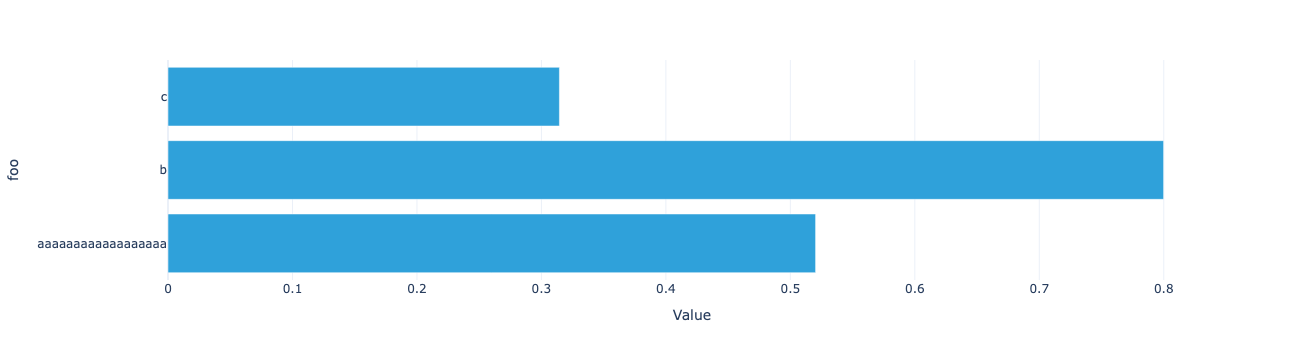

In [951]:
#|hide
plotly_dataarray(U1.array)

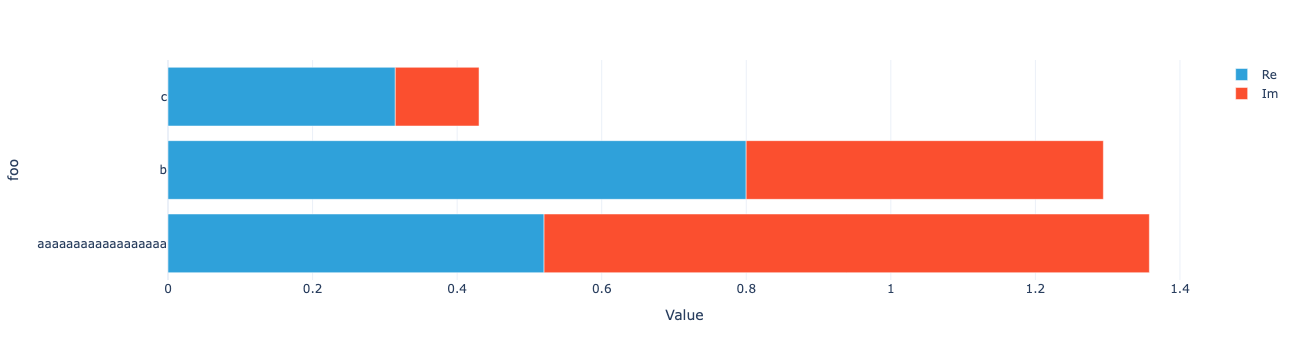

In [952]:
#|hide
plotly_dataarray(U1.array + U2.array)

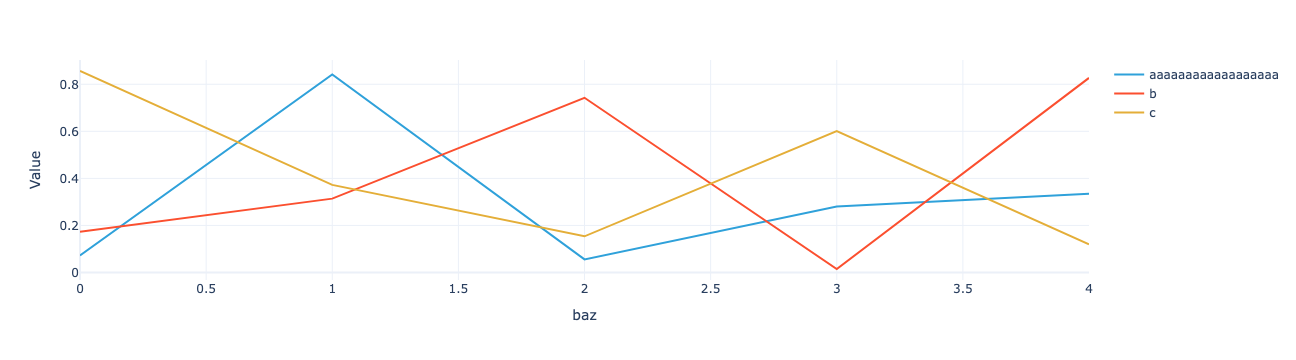

In [953]:
#|hide
plotly_dataarray(U3.array)

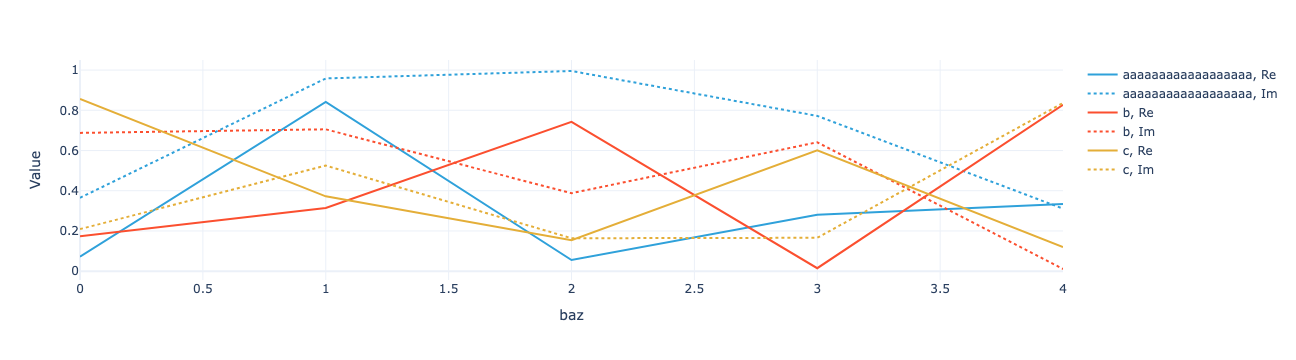

In [954]:
#|hide
plotly_dataarray(U3.array + U4.array)

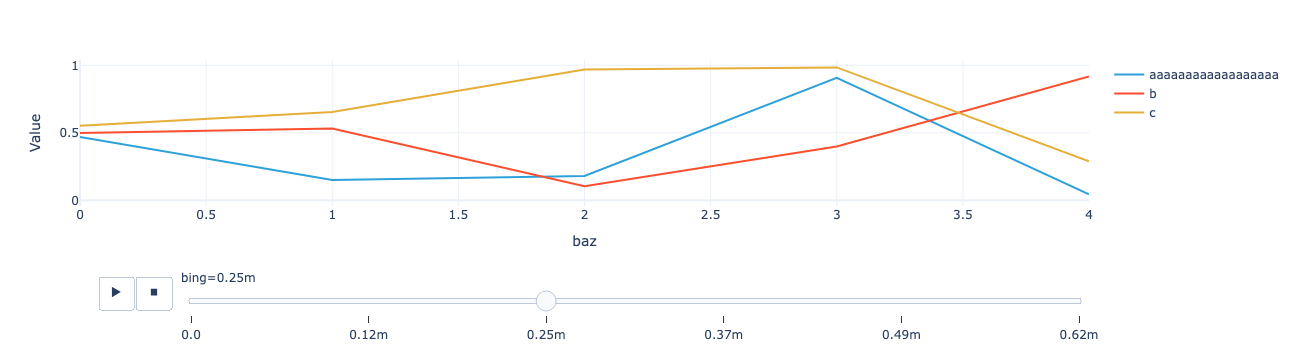

In [955]:
#|hide
plotly_dataarray(U5.array)

### visualize -

In [956]:
#|export
## Could put plotting hints in the attrs of the coordinates inside the model
@patch
@delegates(plotly_dataarray)
def visualize(self:XarrayVectorArray, **kwargs):
    """Visualize the data contained in the `XarrayVectorArray`.
    Put the first dimension with numerical coordinates on the x axis, and include a scrubber if there is a second numerical dimension.
    Atomic velocity is prioritized to be on the x axis, time is prioritized to be on the scrubber.
    Put categorical dimensions in the legend. If the data are complex, add the real and imaginary parts as a categorical dimension.
    If there are no numerical dimensions, plot the categorical dimension(s) as a horizontal bar plot.
    """
    return plotly_dataarray(self.array, **kwargs)

In [957]:
space = XarrayVectorSpace({'foo': ['aaaaaaaaaaaaaaaaaa', 'b', 'c']})
U1 = space.random(name='bar')
U2 = 1j * space.random(name='bar')
U3 = space.random({'baz': np.arange(5)}, name='bar')
U4 = 1j * space.random({'baz': np.arange(5)}, name='bar')
U5 = space.random({'baz': np.arange(5), 'bing': .000123456 * np.linspace(0, 5, 6)}, name='bar')

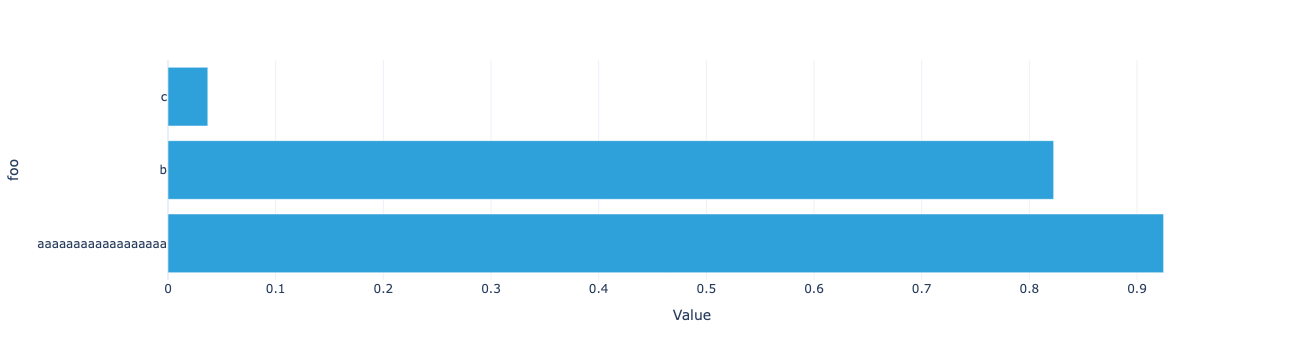

In [958]:
U1.visualize()

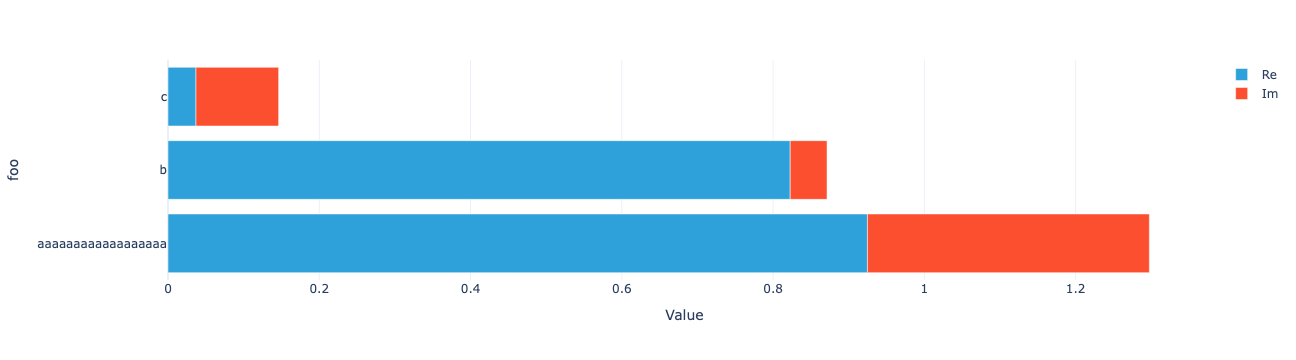

In [959]:
(U1 + U2).visualize()

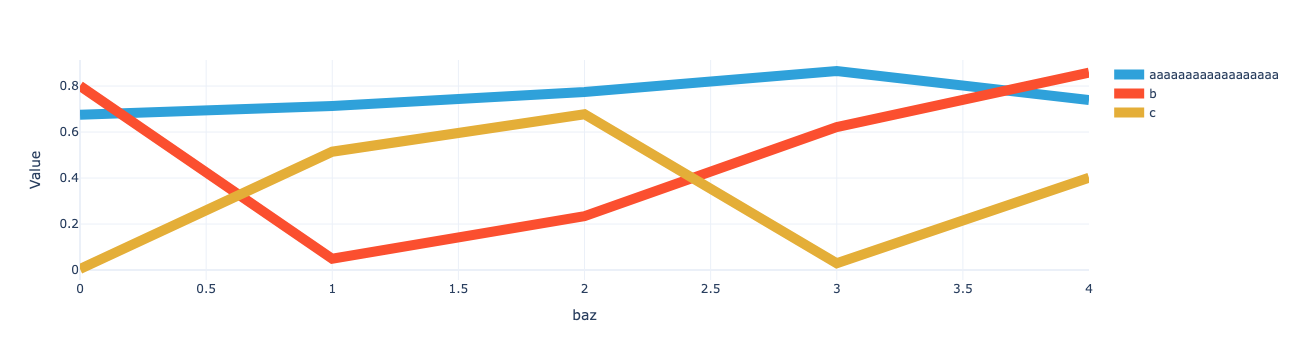

In [960]:
U3.visualize(line_width=10)

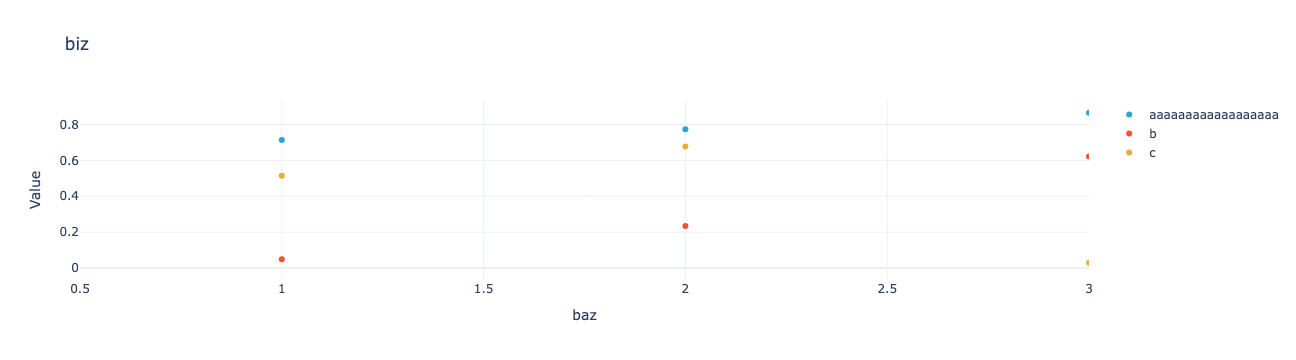

In [961]:
U3.visualize(title='biz', markers=True, xaxis_range=(.5, 3), line_width=0)

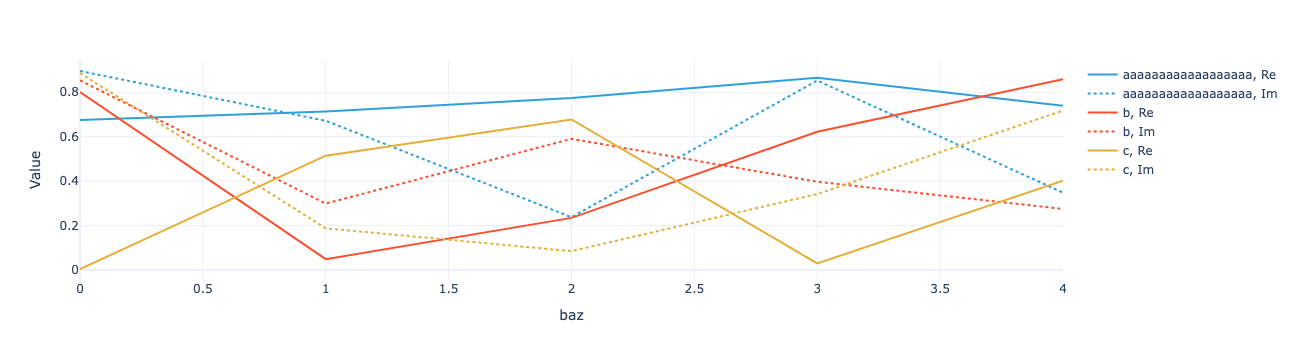

In [962]:
(U3 + U4).visualize()

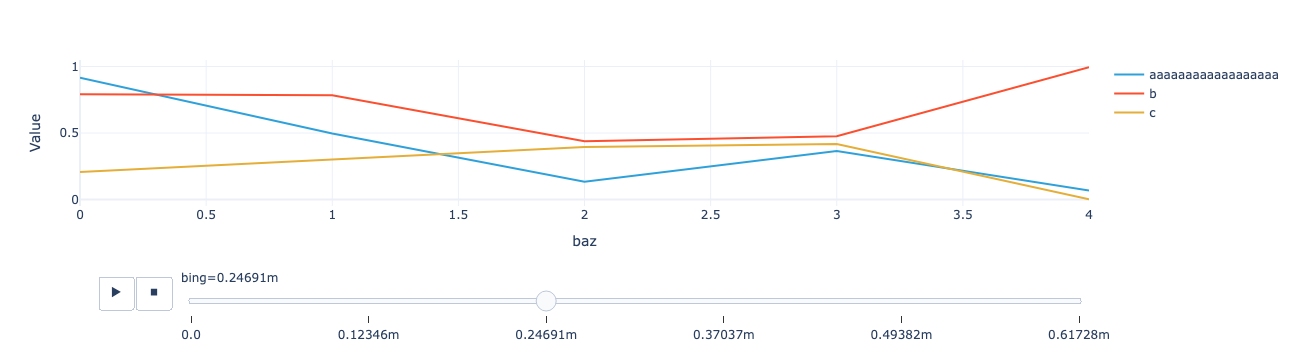

In [963]:
U5.visualize(slider_label_precision=5)

## Export -

In [964]:
#| hide
import nbdev; nbdev.nbdev_export()